# Proyecto de predicción de supervivientes del titanic con regresion lineal de las edades 

In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("brendan45774/test-file")

# print("Path to dataset files:", path)

### este es el dataset mas usado 

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("heptapod/titanic")

# print("Path to dataset files:", path)

### Leer el archivo

In [3]:
#path = "C:\\Users\\thena\\OneDrive\\Escritorio\\proyectos propios\\predicción titanic\\tested.csv"
path = "C:\\Users\\thena\\OneDrive\\Escritorio\\proyectos propios\\predicción titanic\\train_and_test2.csv"

### convertirlo a DataFrame de pandas

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv(path)
df.info()# quiero leer los encabezados
# cambiar el header del 2urvived y Passangerid en caso de 
df.rename(columns={'2urvived': 'Survived', 'Passengerid': 'PassengerId'}, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

el encabezado puedo ver que tengo la información de sexo, edad, clase, precio del boleto, puerto,familia,cabina. 
también me parece que no tengo que hacer limpieza de datos pero para asegurarme voy a ver si alguna columna tiene datos nan

<Axes: >

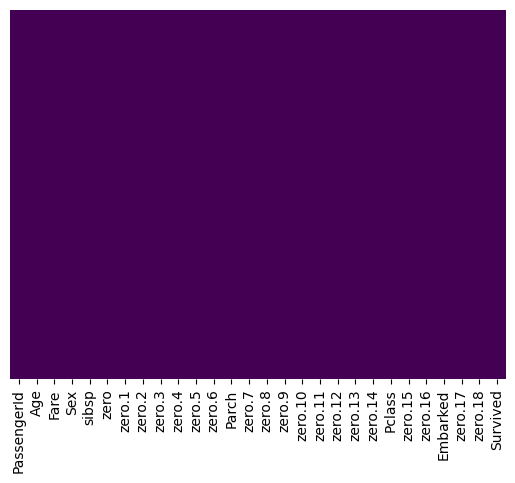

In [5]:
# para ver si tiene valores nan voy a usar un grafico de calor
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

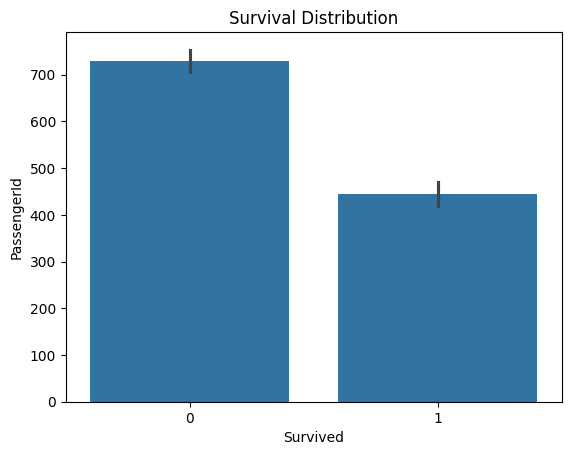

In [6]:
# quiero ver quienes sobrevivieron y quienes no, para eso voy a usar un grafico de barras

sns.barplot(x="Survived", y="PassengerId", data=df)
plt.xlabel("Survived")
plt.ylabel("PassengerId")
plt.title("Survival Distribution")
plt.show()

desde aca el dataframe elegido esta totalmente limpio por lo que no necesito la limpieza de datos, me saltaré esta parte 

In [7]:
# quiero ver la cantidad de datos nulos que hay en años y cabina 
# años_nulos = df['Age'].isnull().sum()

# cabina_nulos = df['Cabin'].isnull().sum()
# print("cantidad de datos nulos en años:", años_nulos)
# print("cantidad de datos nulos en cabina:", cabina_nulos)

como hay demasiados datos nulos en la columna de cabina, esta se eliminará, mientras que la edad se reemplazara con una regresion lineal 


In [8]:
# import numpy as np
# df = df.drop(columns=['Cabin'])

# # ahora calcularé la edad con variables de predicciones como la clase, los hermanos, etc 
# # pero primero voy a reemplazar el valor nulo de fare con la mediana 

# df['Fare'].fillna(df['Fare'].median(), inplace=True)

# caract = ['Pclass', 'SibSp', 'Parch', 'Fare']

# edad_conocida = df[df['Age'].notnull()]
# edad_desconocida = df[df['Age'].isnull()]

# X_train = edad_conocida[caract]
# y_train = edad_conocida['Age']

# X_test = edad_desconocida[caract]

# # entrenar el modelo de regresión lineal para predecir la edad
# from sklearn.linear_model import LinearRegression

# modelo_edad = LinearRegression()
# modelo_edad.fit(X_train, y_train)

# edades_predichas = modelo_edad.predict(X_test)
# edades_predichas = np.clip(edades_predichas, 0.5, 80)  # Limitar las edades predichas entre 0.5 y 80

# df.loc[df['Age'].isnull(), 'Age'] = edades_predichas



# print("datos limpiados de edad:", df['Age'].isnull().sum())

In [9]:
#sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

ahora quiero ver quienes tenian mayor chance de supervivencia o un hombre o una mujer (siendo 0 el hombre y 1 la mujer)

Text(0.5, 1.0, 'Comparación de la mortalidad de mujeres vs hombres')

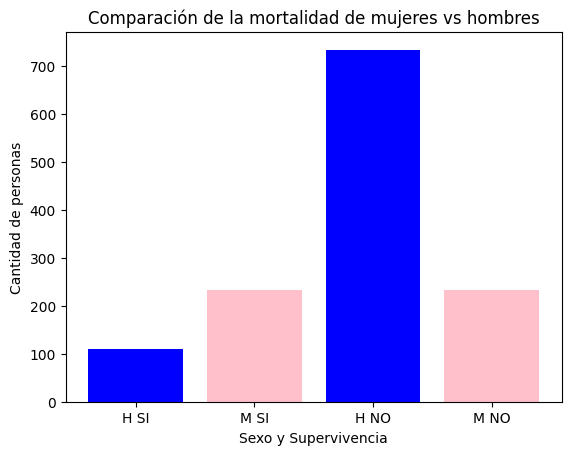

In [10]:
df_hombres = df[df['Sex'] == 0]
df_mujeres = df[df['Sex'] == 1]

# hay 466 mujeres y 843 hombres, por lo que hay más hombres que mujeres en el dataset

# graficar comparacion de la mortalidad de mujeres vs hombres, para eso voy a usar un grafico de barras
plt.bar(['H SI', 'M SI','H NO', 'M NO'],
         [len(df_hombres[df_hombres['Survived'] == 1]), len(df_mujeres[df_mujeres['Survived'] == 1]),
        len(df_hombres[df_hombres['Survived'] == 0]), len(df_mujeres[df_mujeres['Survived'] == 0])], color=['blue', 'pink', 'blue', 'pink'])
plt.xlabel("Sexo y Supervivencia")
plt.ylabel("Cantidad de personas")
plt.title("Comparación de la mortalidad de mujeres vs hombres")


In [11]:
# con el grafico claramente hay más hombres que mujeres que murieron, y más mujeres que hombres que sobrevivieron
# haré fracciones para ver la proporción de hombres y mujeres que sobrevivieron y murieron
hombres_total = len(df_hombres[df_hombres['Survived'] == 1])/len(df_hombres) 
mujeres_total = len(df_mujeres[df_mujeres['Survived'] == 1])/len(df_mujeres) 
print("la probabilidad de que un hombre sobreviva es:", hombres_total * 100, "%")
print("la probabilidad de que una mujer sobreviva es:", mujeres_total * 100, "%")


la probabilidad de que un hombre sobreviva es: 12.930011862396205 %
la probabilidad de que una mujer sobreviva es: 50.0 %


en conclusion las mujeres tienen 50% de chance de sobrevivir en comparación a los hombres quienes tienen 12.93%

# ¿influye la clase? 
probablemente los pasajeros de primera sobreviven mas que las demas clases 


la probabilidad de que una persona de clase 1 sobreviva es: 42.10526315789473 %
la probabilidad de que una persona de clase 2 sobreviva es: 31.40794223826715 %
la probabilidad de que una persona de clase 3 sobreviva es: 16.784203102961918 %


C:\Users\thena\AppData\Local\Temp\ipykernel_19320\2283753191.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clase1_total = len(df[df['Pclass'] == 1][df['Survived'] == 1])/len(df[df['Pclass'] == 1])
C:\Users\thena\AppData\Local\Temp\ipykernel_19320\2283753191.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clase2_total = len(df[df['Pclass'] == 2][df['Survived'] == 1])/len(df[df['Pclass'] == 2])
C:\Users\thena\AppData\Local\Temp\ipykernel_19320\2283753191.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clase3_total = len(df[df['Pclass'] == 3][df['Survived'] == 1])/len(df[df['Pclass'] == 3])


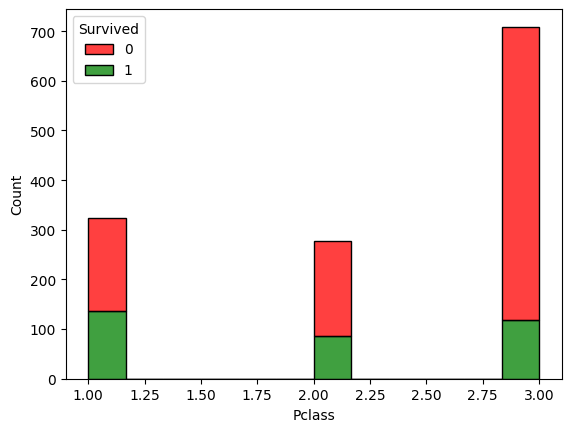

In [12]:
# para filtrar las clases me enfocaré en la columna Pclass
sns.histplot(data=df, x="Pclass", hue="Survived", multiple="stack", palette={0: "red", 1: "green"})

# hallar las fracciones de las clases que sobrevivieron y murieron
clase1_total = len(df[df['Pclass'] == 1][df['Survived'] == 1])/len(df[df['Pclass'] == 1]) 
clase2_total = len(df[df['Pclass'] == 2][df['Survived'] == 1])/len(df[df['Pclass'] == 2]) 
clase3_total = len(df[df['Pclass'] == 3][df['Survived'] == 1])/len(df[df['Pclass'] == 3]) 
print("la probabilidad de que una persona de clase 1 sobreviva es:", clase1_total * 100, "%")
print("la probabilidad de que una persona de clase 2 sobreviva es:", clase2_total * 100, "%")
print("la probabilidad de que una persona de clase 3 sobreviva es:", clase3_total * 100, "%")

como se ve hay mas chanse de sobrevivir si son de la clase 1, despúes viene la clase 2 y finalmente la 3.
ahora analizaré si la cantidad de hijos tambien afecta 

<Axes: xlabel='family_size', ylabel='Count'>

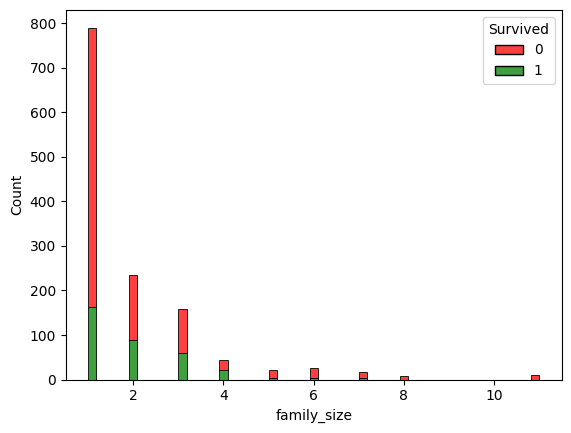

In [13]:
# leyendo me encontre que hay otras columnas que influyen en el nucleo familiar, voy a crear una columna nueva
# considerando este dato
df["family_size"] = df["sibsp"] + df["Parch"] + 1 # 1 para contar a la misma persona 
sns.histplot(data=df, x="family_size", hue="Survived", multiple="stack", palette={0: "red", 1: "green"})

como las familias menos numerosas son las que tinenen mas chance de sobrevivir crearé otra columna para "aislar" a las personas que no fueron con familia


In [14]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

## Entrenamiento del modelo 
ya confirmé que las columnas son todas útiles menos las que se llaman zero por lo tanto las sacaré

In [15]:
# crear lista con el nombre de las columnas que eliminaré del dataset 
a = 1
lista_nombres_zeros = []
while a <=18:
    nombre = "zero."+str(a)
    lista_nombres_zeros.append(nombre)
    a+=1

In [16]:
df = df.drop(columns=lista_nombres_zeros)
df = df.drop(columns=['zero'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
 9   family_size  1309 non-null   int64  
 10  is_alone     1309 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 112.6 KB


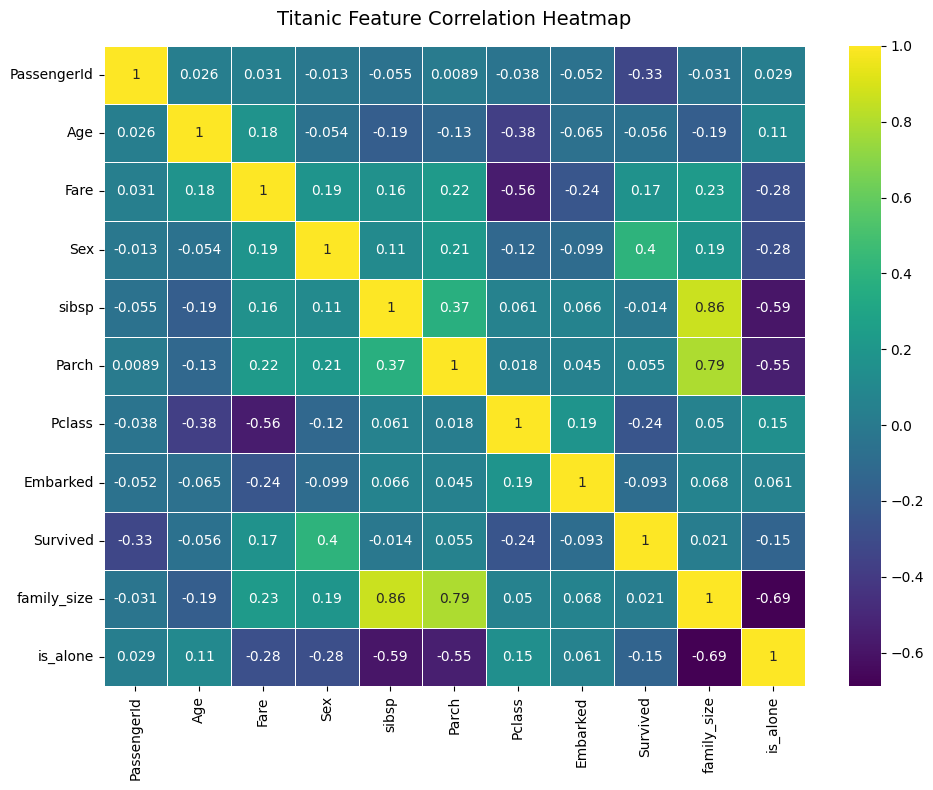

In [18]:
# matriz de correlacion para ver que columnas tienen mayor correlacion con la supervivencia
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,          
    cmap='viridis',                
    linewidths=0.5      
)

plt.title('Titanic Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

En esta matriz de correlación se ve una buena relacion entre las variables elegidas y la supervivencia siendo claramente la mas importante el sexo y el costo del pasaje podria probar eliminando embarked y pclass para ver si mejora el aprendizaje

In [19]:
#tambien considero que la columna Embarked no debe influir ya que es la que dice en que lugar se embarcó la persona
# si pensamos en el dinero, el tiket tiene su clasificacion segun la clase que pagaron 
df.drop(columns=['Embarked','Pclass'], inplace=True)




In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Survived     1309 non-null   int64  
 7   family_size  1309 non-null   int64  
 8   is_alone     1309 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 92.2 KB


también ya mezclé dos columnas que era para la cantidad de familires y me imagino que passangerid no debe por qué afectar en el entrenamiento ya que es solamente un recuento de pasajeros 

In [21]:
df.drop(columns=['PassengerId', 'sibsp', 'Parch'], inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1309 non-null   float64
 1   Fare         1309 non-null   float64
 2   Sex          1309 non-null   int64  
 3   Survived     1309 non-null   int64  
 4   family_size  1309 non-null   int64  
 5   is_alone     1309 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 61.5 KB


<Axes: xlabel='Fare', ylabel='Count'>

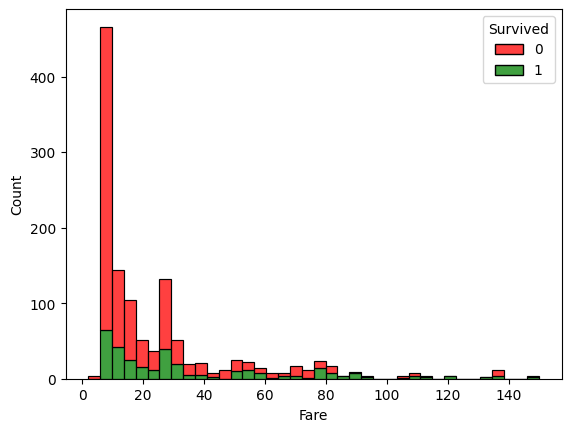

In [23]:
# fare me faltó analizar por lo que lo veré enseguida
sns.histplot(data=df, x="Fare", hue="Survived", multiple="stack",binrange=[2,150], palette={0: "red", 1: "green"})
# borrar el binrage si se quiere ver toda la distribución

vemos que embarked tiene 2 null por lo que tendré que arreglarlos con la moda devido a lo poco que son estos datos


### _compilar en caso de no haber eliminado embarked__

In [24]:
sns.histplot(data=df, x="Embarked", hue="Survived", multiple="stack", palette={0: "red", 1: "green"}) 

ValueError: Could not interpret value `Embarked` for `x`. An entry with this name does not appear in `data`.

In [ ]:
#reemplazar los null con 2 
df["Embarked"].fillna(2, inplace=True)

C:\Users\thena\AppData\Local\Temp\ipykernel_25896\4182877451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(2, inplace=True)


se ve una clara inclinacion por los boletos mas caros mas chanse de sobrevivir, tambien se considerará para el entrenamiento 


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [26]:
X = df.drop(columns=['Survived']) # variable independiente
y = df['Survived'] # variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
# stratify=y para mantener la proporción de clases en el conjunto de entrenamiento y prueba


In [27]:
# comenzaré con un modelo de regresión logística
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [28]:
pred = modelo.predict(X_test)


In [29]:
print("exactitud del modelo:", accuracy_score(y_test, pred))
print("precisión del modelo:", precision_score(y_test, pred))
print("sensibilidad del modelo:", recall_score(y_test, pred))
print("puntaje F1 del modelo:", f1_score(y_test, pred))

#matriz de confusion 
cm = confusion_matrix(y_test, pred)
print("matriz de confusion del modelo:", cm)

exactitud del modelo: 0.7519083969465649
precisión del modelo: 0.5306122448979592
sensibilidad del modelo: 0.38235294117647056
puntaje F1 del modelo: 0.4444444444444444
matriz de confusion del modelo: [[171  23]
 [ 42  26]]


In [30]:
# probaré con un modelo de Random Forest para ver si mejora la exactitud del modelo
from sklearn.ensemble import RandomForestClassifier
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
print("exactitud del modelo de Random Forest:", accuracy_score(y_test, pred_rf))
print("precisión del modelo de Random Forest:", precision_score(y_test, pred_rf))
print("sensibilidad del modelo de Random Forest:", recall_score(y_test, pred_rf))
print("puntaje F1 del modelo de Random Forest:", f1_score(y_test, pred_rf))
print("matriz de confusion del modelo de Random Forest:", confusion_matrix(y_test, pred_rf))


exactitud del modelo de Random Forest: 0.7442748091603053
precisión del modelo de Random Forest: 0.5079365079365079
sensibilidad del modelo de Random Forest: 0.47058823529411764
puntaje F1 del modelo de Random Forest: 0.48854961832061067
matriz de confusion del modelo de Random Forest: [[163  31]
 [ 36  32]]


## conclusión 
El modelo de radomforest fue el modelo que mejor predice los datos con una exactitud de 0.74, pero con una presicion por encima del 50% y también en sensibilidad, estos valores son bajos para poder confiar bien en el modelo usado por lo que veré opciones de mejorar el modelo


In [31]:
y.value_counts(normalize=True)

Survived
0    0.738732
1    0.261268
Name: proportion, dtype: float64

In [32]:
print(X_train.shape)
print(X_test.shape)

(1047, 5)
(262, 5)


In [33]:
print("Accuracy entrenamiento:", modelo_rf.score(X_train, y_train))
print("Accuracy prueba:", modelo_rf.score(X_test, y_test))

Accuracy entrenamiento: 0.9770773638968482
Accuracy prueba: 0.7442748091603053


In [34]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

Fare           0.419782
Age            0.348054
Sex            0.156183
family_size    0.064891
is_alone       0.011089
dtype: float64


con los datos que tengo ahora veo que el modelo memorizó en vez de aprender y, además, las importancias estan un poco raras, deberia ser el sexo y la edad lo mas importante que todo lo demas considerando esto controlaré hiperparametros del randomforest para ver si consigo que aprenda 

In [35]:
modelo_2 = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, min_samples_leaf=5, 
                                  class_weight='balanced', random_state=42)
modelo_2.fit(X_train, y_train)
pred_2 = modelo_2.predict(X_test)

print("exactitud del modelo de Random Forest 2:", accuracy_score(y_test, pred_2))
print("precisión del modelo de Random Forest 2:", precision_score(y_test, pred_2))
print("sensibilidad del modelo de Random Forest 2:", recall_score(y_test, pred_2))
print("puntaje F1 del modelo de Random Forest 2:", f1_score(y_test, pred_2))
print("matriz de confusion del modelo de Random Forest 2:", confusion_matrix(y_test, pred_2))

exactitud del modelo de Random Forest 2: 0.7404580152671756
precisión del modelo de Random Forest 2: 0.5
sensibilidad del modelo de Random Forest 2: 0.7647058823529411
puntaje F1 del modelo de Random Forest 2: 0.6046511627906976
matriz de confusion del modelo de Random Forest 2: [[142  52]
 [ 16  52]]


In [36]:
# validacion cruzada para ver si el modelo es robusto
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    modelo_2,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)
print("F1 promedio:", scores.mean())

[0.64900662 0.67114094 0.69281046 0.47       0.56989247]
F1 promedio: 0.6105700985496981


## conclusión 2 
se observa como al modificar los hiperparametros al ojo mejoró el aprendizaje pero aún así no se ve muy buena, por lo que buscaré otra configuracion de hiperparametros a través del model selection de sklearn

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
0.607569600666771


# Conclusión final 
lo mas probable es que el dataset, no fue lo mejor manejado pues hay muy pocas columnas al final, viendo otros datasets del mismo caso, me encontré que algunos tenian el nombre de la persona con sus respectivos títulos (grado academico, profesional, etario, etc) por lo que buscar un dataset más correcto sería lo mejor, además, el hecho de eliminar embarked puede producir una alteración ya que las localidades donde embarcan las personas pueden estar estrechamente relacionadas por lo que comenté esta parte. en conclusion se logro un buen puntaje a pesar de que el set de datos no era el mejor, aunque se puede pulir más.

pd: viendo otros analisis con otros modelos de aprendizaje como KNN pude ver que este problema es recurrente por lo que se debe mejorar el dataset, además la eliminación de pclass y embarked mejoraron las predicciones pero no mucho, por lo que el data set deberia mejorarse definitivametne 
